<a href="https://colab.research.google.com/github/Ehsunpy/EhsanLak/blob/main/data_digits_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from tensorflow import keras
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits


In [5]:
data_digits =load_digits()

In [6]:
data_digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [36]:
data_digits.images.shape

(1797, 8, 8)

In [32]:
# X is upper
X = data_digits.images
y = data_digits.target

In [41]:
import cv2

# Assuming 'data_digits.images' is your list of images
x = [cv2.resize(img, (8, 8)) for img in data_digits.images]

# Check the shape of the first image to confirm resizing
print(x[0].shape)


(8, 8)


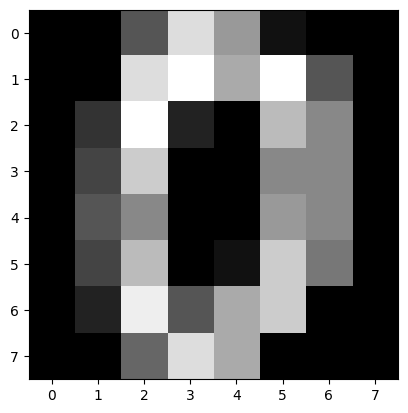

In [47]:
plt.imshow(x[0],cmap='gray')

In [48]:
8*8

64

In [55]:
import numpy as np

x=np.reshape(x,[-1,64])

In [56]:
x.shape

(1797, 64)

In [33]:
y = keras.utils.to_categorical(y)

In [57]:
y.shape

(1797, 10)

In [58]:
assert y.shape ==(1797,10)

In [59]:
# x isnot be upper its lower
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [74]:
X_train =X_train.astype('float32')
X_test = X_test.astype('float32')

X_train /=225
X_test /=225

In [75]:
import keras
from keras import layers
from keras.models import Sequential


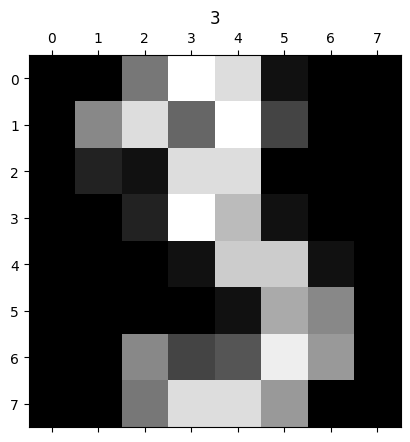

In [76]:
i = 3
plt.matshow(data_digits.images[i],cmap='gray')
plt.title(data_digits.target[i]);

In [83]:
from keras.layers import Dense, Dropout, Flatten

model = Sequential()
model.add(layers.Dense(64, activation='relu',input_dim=64))
model.add(Dropout(.5))

model.add(layers.Dense(50, activation='relu'))
model.add(Dropout(.5))
model.add(layers.Dense(10, activation='softmax'))
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 50)                  │           3,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 10)                  │             510 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,920 (30.94 KB)

 Trainable params: 7,920 (30.94 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
from keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [85]:
h = model.fit(
    X_train,y_train,batch_size=10,epochs=40
)

Epoch 1/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1250 - loss: 2.2936
Epoch 2/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2157 - loss: 2.2030
Epoch 3/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4008 - loss: 1.9132
Epoch 4/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4937 - loss: 1.6271
Epoch 5/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5635 - loss: 1.3882
Epoch 6/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5751 - loss: 1.2478
Epoch 7/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6230 - loss: 1.1366
Epoch 8/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6800 - loss: 1.0080
Epoch 9/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6879 - loss: 0.9285
Epoch 10/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7012 - loss: 0.8788
Epoch 11/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7472 - loss: 0.8035
Epoch 12/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [86]:
reult = model.evaluate(X_test,y_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9683 - loss: 0.1328  


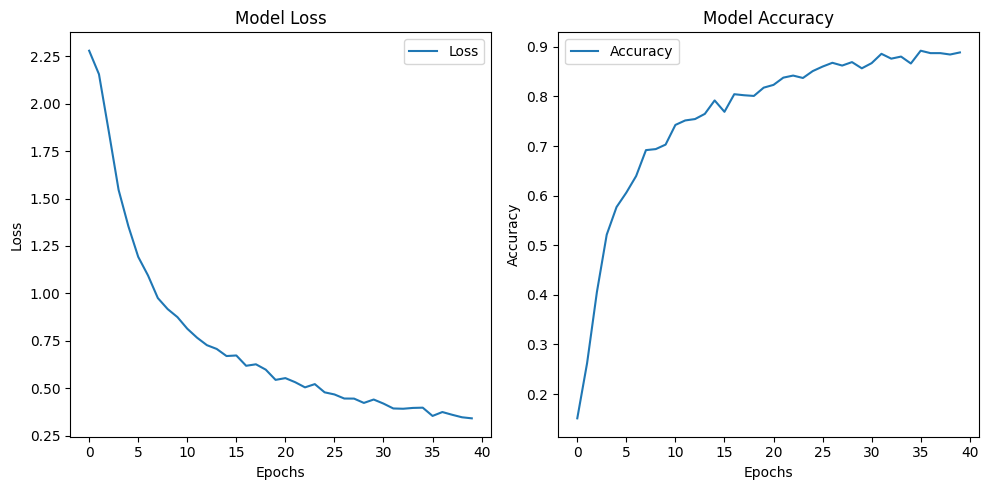

In [87]:
import matplotlib.pyplot as plt

# Assuming 'h' is your model's history object
plt.figure(figsize=(10, 5))

# Plotting the loss
plt.subplot(1, 2, 1)
plt.plot(h.history['loss'], label='Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting the accuracy
plt.subplot(1, 2, 2)
plt.plot(h.history['accuracy'], label='Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()
